In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from qutip import *
import time
import seaborn as sns

In [2]:
# constants
g = 2
mu_B = 9.27e-24
B = 500e-3
h = 6.62607015e-34 # J s
hbar = 1.054571817e-34 # J s
ELEMENTARY_CHARGE_C = 1.602176634e-19
EV_TO_JOULE = ELEMENTARY_CHARGE_C
e = 1.6e-19

# just in case
sx = sigmax()
sy = sigmay()
sz = sigmaz()
sm = sigmam()
sp = sigmap()


The Hamiltonian in the $| L \rangle, | R \rangle $ basis reads:

$
\begin{align}
\text{H} = 
\begin{pmatrix}
\epsilon(t)/2 & \Delta \\
\Delta & -\epsilon(t)/2
\end{pmatrix}
= \frac{\epsilon(t)}{2} \sigma_z + \Delta \sigma_x
\end{align}
$

with $\epsilon(t) = \epsilon_0 + vt$.

We define the relaxation and dephasing operators as

$a_\text{rel} = \sqrt{\gamma_1} | \text{G} \rangle \langle \text{E} | \quad \text{and} \quad a_\text{deph} = \sqrt{\gamma_2} | \text{E} \rangle \langle \text{E} | - | \text{G} \rangle \langle \text{G} | $,

where $ | \text{G} \rangle $ and $ | \text{E} \rangle $ are the intantaneous ground and excited states of the system.  $\gamma_1 = 1/T_1$ and $\gamma_2 = 1/T_2$.

In [3]:
# Hamiltonian
def hamiltonian(epsilon0, delta, v, freq_units=True):
    H0 = (0.5*epsilon0*sz + delta*sx)
    H1 = (0.5*v*sz)
    if freq_units:
        H0 = H0 * EV_TO_JOULE / hbar
        H1 = H1 * EV_TO_JOULE / hbar
    H = [H0, [H1, 't']]
    return H

# detuning
def epsilon(t, args):
    v = args['velocity']
    epsilon0 = args['epsilon_inital']
    eps = epsilon0 + v*t
    return eps
    
# basis change matrix elements
def U1(t, args):
    delta = args['delta']
    a = ((epsilon(t, args) + np.sqrt(4*delta**2 + epsilon(t, args)**2)) / 
          np.sqrt(8*delta**2 + 2*epsilon(t, args)*(epsilon(t, args) + np.sqrt(4*delta**2 + epsilon(t, args)**2))))
    return a

def U2(t, args):
    delta = args['delta']
    b = delta / np.sqrt(2*delta**2 + 0.5*epsilon(t, args)*(epsilon(t, args) + np.sqrt(4*delta**2 + epsilon(t, args)**2)))
    return b

# relaxation operator coefficients
def rel_sz(t, args):
    gamma_rel = args['relaxation']
    coef = -np.sqrt(gamma_rel)*U1(t, args)*U2(t, args)
    return coef

def rel_sm(t, args):
    gamma_rel = args['relaxation']
    coef = np.sqrt(gamma_rel)*U1(t, args)**2
    return coef

def rel_sp(t, args):
    gamma_rel = args['relaxation']
    coef = -np.sqrt(gamma_rel)*U2(t, args)**2
    return coef

# dephasing operator coefficients
def deph_sz(t, args):
    gamma_deph = args['dephasing']
    coef = np.sqrt(gamma_deph)*(U1(t, args)**2 - U2(t, args)**2)
    return coef

def deph_sx(t, args):
    gamma_deph = args['dephasing']
    coef = np.sqrt(gamma_deph)*2*U1(t, args)*U2(t, args)
    return coef

# Landau-Zener transition probability
def plz(v):
    prob = np.exp(-2*np.pi*delta**2 / (hbar*v))
    return prob

# convert a rate to a time string
def time_str(gamma):
    if gamma == 0:
        return '$\infty$'
    t = 1e9/gamma
    if t >= 1 and t < 1e3:
        t = str(round(t, 1)) + ' ns'
    elif t >= 1e3 and t < 1e6:
        t = str(round(1e-3*t, 1)) + ' $\mu$s'
    elif t >= 1e6 and t < 1e9:
        t = str(round(1e-6*t, 1)) + ' ms'
    return t

# compute and plot eigenenergies
def energy_levels(epsilon0, epsilon_f, delta, v):
    # time list
    t_f = (epsilon_f - epsilon0)/v
    tlist = np.linspace(0, 2*t_f, 1000)
    
    energies_list = []
    
    for t in tlist:
        [H0, [H1, s]] = hamiltonian(epsilon0, delta, v, False)
        H = H0 + t*H1
        energies = H.eigenenergies(sort='high')
        energies_list.append(1e9*energies)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    plt.plot(1e3*tlist, energies_list)
    ax.set_xlabel("Time [ms]")
    ax.set_ylabel("Energy [neV]")
    
    return fig, ax

In [4]:
# simulation
def qubit_integrate(psi0, epsilon0, epsilon_f, delta, v, gamma_rel, gamma_deph, pb=True):
    
    t_f = (epsilon_f - epsilon0)/v
    tlist = np.linspace(0, 2*t_f, 10000)
    
    # collapse operators
    c_ops = []
    
    # relaxation
    if gamma_rel > 0.0:
        c_ops.append([[sz, rel_sz], [sm, rel_sm], [sp, rel_sp]])
    
    # dephasing
    if gamma_deph > 0.0:
        c_ops.append([[sz, deph_sz], [sx, deph_sx]])
    
    # Hamiltonian
    H = hamiltonian(epsilon0, delta, v)
    
    # expectation values
    e_ops = []
    e_ops.append(basis(2,0)*basis(2,0).dag())
    
    # options
    options = Options()
    options.nsteps = 5e4
    
    # evolve
    output = mesolve(H, psi0, tlist, c_ops, e_ops, options=options, 
                     args={'velocity': v, 'epsilon_inital': epsilon0, 'delta': delta,
                           'relaxation': gamma_rel, 'dephasing': gamma_deph}, progress_bar=pb)
    
    return output.expect[0], output.times

In [5]:
# run multiple simulations 
def scan_parameters(psi0, epsilon0, epsilon_f, delta, v_list, rel_list, deph_list, add_relax=False):
    probs_sim = []
    i = 1
    for gamma_rel in rel_list:
        print("relaxation step " + str(i) + ": gamma = " + str(gamma_rel))
        inter1 = []
        j = 1
        for gamma_deph in deph_list:
            print("dephasing step " + str(j) + ": gamma = " + str(gamma_deph))
            inter2 = []
            for v in v_list:
                result, tl = qubit_integrate(psi0, epsilon0, epsilon_f, delta, v, gamma_rel, gamma_deph, None)
                prob = np.real(result)[-1]
                if add_relax:
                    t_tot = (epsilon_target - 2*epsilon_f + epsilon0)/v
                    rel_acc = np.exp(-t_tot*gamma_rel)
                    prob = prob*rel_acc
                inter2.append(prob)
                print(str(prob))
            inter1.append(inter2)
            j = j + 1
        probs_sim.append(inter1)
        i = i + 1
    return probs_sim

In [17]:
# parameters
epsilon0 = -120e-9 #eV -50ueV
epsilon_f = 120e-9 #eV 200ueV

epsilon_target = 200e-6

delta = 1.5e-9 #eV

v = 1/50 #eV/s
vlist = 1/np.linspace(1, 200, 10)

gamma_rel   = 0e4 #s^-1 relaxation rate 10 - 100 us
gammas_rel  = [1e1, 1e2, 1e3]
#gammas_rel = np.logspace(2, 5, 7)

gamma_deph  = 1e5 #s^-1 dephasing rate
gammas_deph = [1e5]
#gammas_deph = np.logspace(4, 8, 9)

psi0 = basis(2, 0)

In [20]:
start_time = time.time()
result = scan_parameters(psi0, epsilon0, epsilon_f, delta, vlist, gammas_rel, gammas_deph)
stop_time = time.time()
print("time elapsed: " + str((stop_time - start_time)/60) + " minutes")

relaxation step 1: gamma = 100.0
dephasing step 1: gamma = 100000.0
0.9802892015883609
0.599301883061922
0.38545329096598574
0.24138694459625665
0.15676064285164595
0.10296921846573083
0.068438026453908
0.04708063400826274
0.03302311278218545
0.024001805012911985
relaxation step 2: gamma = 1000.0
dephasing step 1: gamma = 100000.0
0.9799729025871892
0.5948556411704009
0.37984528430342035
0.2361875513441988
0.152285576275981
0.0993154084577987
0.06554255003423684
0.04476319140433164
0.031172157733983095
0.022494258660141965
relaxation step 3: gamma = 10000.0
dephasing step 1: gamma = 100000.0
0.976816000206873
0.5520621240935414
0.32806799969844
0.189975766865625
0.11400103249302679
0.06919859925662117
0.04252267344777695
0.027022348162300487
0.017521532281062156
0.011764871869497024
time elapsed: 21.302206587791442 minutes


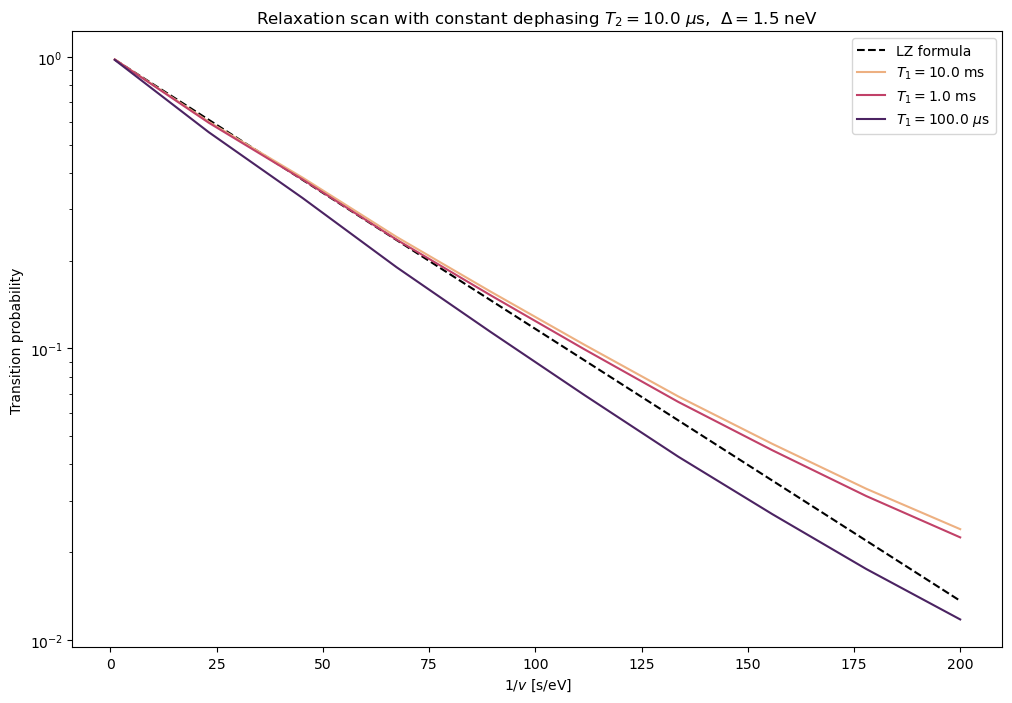

In [21]:
# 1/v plots
len_rel = len(gammas_rel)
len_deph = len(gammas_deph)

fig, ax = plt.subplots(figsize=(12,8))
ax.plot(1/vlist, plz(vlist), 'k--')

labels = ['LZ formula']
# colors = plt.cm.viridis(np.linspace(0,1,len(gammas_deph)))
cmap = sns.color_palette("flare", as_cmap=True)
colors = cmap(np.linspace(0, 1, max([len_rel, len_deph])))

for i in range(len_rel):
    for j in range(len_deph):
        # plot the simulation results
        plt.plot(1/vlist, result[i][j], color=colors[max([i, j])])
        
        # labels for the legend
        if len_deph >= len_rel:
            # dephasing scan case
            t2 = time_str(gammas_deph[j])
            labels.append('$T_2 = $' + t2)
        elif len_rel > len_deph:
            #relaxation scan case
            t1 = time_str(gammas_rel[i])
            labels.append('$T_1 = $' + t1)
        
ax.set_xlabel("$1/v$ [s/eV]")
ax.set_ylabel("Transition probability")
ax.legend(labels, loc=0)

title = ''

if len_deph >= len_rel:
    title = title + 'Dephasing scan with '
    if gammas_rel[0] == 0:
        title = title + 'no relaxation'
    else:
        title = title + 'constant relaxation $T_1 = $' + time_str(gammas_rel[0])

elif len_rel > len_deph:
    title = title + 'Relaxation scan with '
    if gammas_deph[0] == 0:
        title = title + 'no dephasing'
    else:
        title = title + 'constant dephasing $T_2 = $' + time_str(gammas_deph[0])
        
title = title + ',  $\Delta = $' + str(1e9*delta) + ' neV'
        
plt.title(title)
plt.yscale('log')

In [18]:
start_time = time.time()
result2 = scan_parameters(psi0, epsilon0, epsilon_f, delta, vlist, gammas_rel, gammas_deph, True)
stop_time = time.time()
print("time elapsed: " + str((stop_time - start_time)/60) + " minutes")

relaxation step 1: gamma = 100.0
dephasing step 1: gamma = 100000.0
0.960912767090801
0.3778038808842545
0.1562728591394665
0.06293853142936268
0.026286386597343704
0.011104328448322301
0.004746498931018918
0.002099951382690139
0.0009472747756044933
0.0004427849957720337
relaxation step 2: gamma = 1000.0
dephasing step 1: gamma = 100000.0
0.802622844751616
0.00589683952704226
4.557479660910869e-05
3.4299301749275286e-07
2.6766853477228e-09
2.112834397989282e-11
1.687650199948737e-13
1.3950520712530926e-15
1.1758353606459646e-17
1.0269791140587e-19
relaxation step 3: gamma = 10000.0
dephasing step 1: gamma = 100000.0
0.13267443934005818
5.059006070566105e-21
2.028354553086261e-40
7.924665852940835e-60
3.208442715182391e-79
1.313970335107174e-98
5.447679768874411e-118
2.335698848363867e-137
1.0218063485094352e-156
4.6289923955791774e-176
time elapsed: 21.113713041941324 minutes


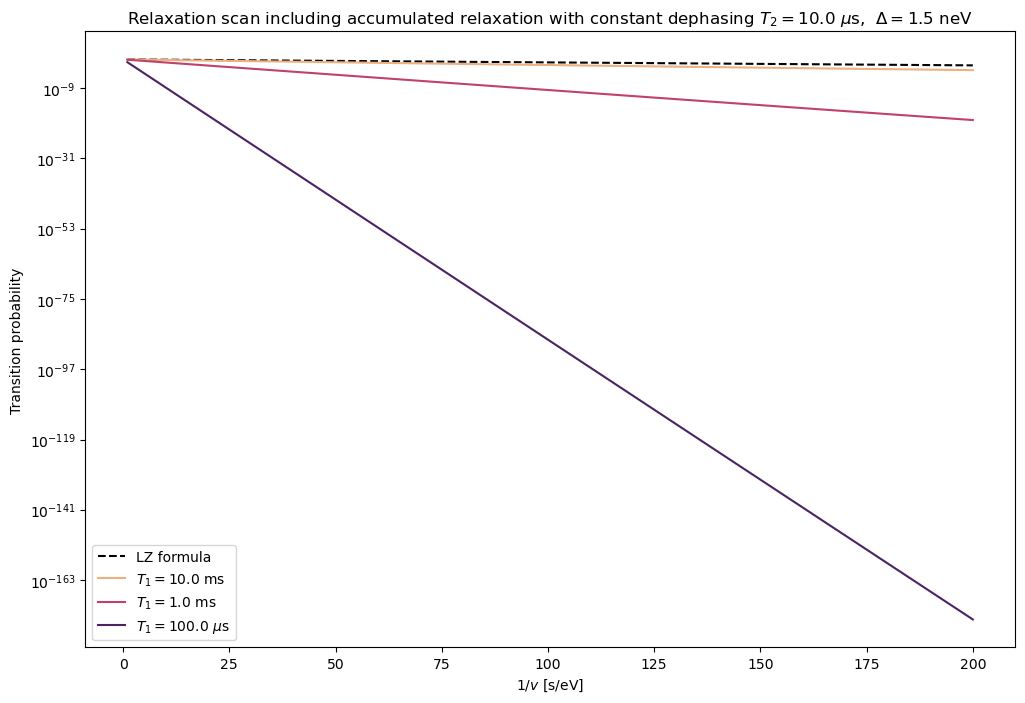

In [19]:
# 1/v plots
len_rel = len(gammas_rel)
len_deph = len(gammas_deph)

fig, ax = plt.subplots(figsize=(12,8))
ax.plot(1/vlist, plz(vlist), 'k--')

labels = ['LZ formula']
# colors = plt.cm.viridis(np.linspace(0,1,len(gammas_deph)))
cmap = sns.color_palette("flare", as_cmap=True)
colors = cmap(np.linspace(0, 1, max([len_rel, len_deph])))

for i in range(len_rel):
    for j in range(len_deph):
        # plot the simulation results
        plt.plot(1/vlist, result2[i][j], color=colors[max([i, j])])
        
        # labels for the legend
        if len_deph >= len_rel:
            # dephasing scan case
            t2 = time_str(gammas_deph[j])
            labels.append('$T_2 = $' + t2)
        elif len_rel > len_deph:
            #relaxation scan case
            t1 = time_str(gammas_rel[i])
            labels.append('$T_1 = $' + t1)
        
ax.set_xlabel("$1/v$ [s/eV]")
ax.set_ylabel("Transition probability")
ax.legend(labels, loc=0)

title = ''

if len_deph >= len_rel:
    title = title + 'Dephasing scan with '
    if gammas_rel[0] == 0:
        title = title + 'no relaxation'
    else:
        title = title + 'constant relaxation $T_1 = $' + time_str(gammas_rel[0])

elif len_rel > len_deph:
    title = title + 'Relaxation scan including accumulated relaxation with '
    if gammas_deph[0] == 0:
        title = title + 'no dephasing'
    else:
        title = title + 'constant dephasing $T_2 = $' + time_str(gammas_deph[0])
        
title = title + ',  $\Delta = $' + str(1e9*delta) + ' neV'
        
plt.title(title)
plt.yscale('log')

In [35]:
# single simulation
result, tlist = qubit_integrate(psi0, epsilon0, epsilon_f, delta, v, gamma_rel, gamma_deph)

10.0%. Run time:   0.53s. Est. time left: 00:00:00:04
20.0%. Run time:   0.91s. Est. time left: 00:00:00:03
30.0%. Run time:   1.02s. Est. time left: 00:00:00:02
40.0%. Run time:   1.53s. Est. time left: 00:00:00:02
50.0%. Run time:   2.53s. Est. time left: 00:00:00:02
60.0%. Run time:   3.97s. Est. time left: 00:00:00:02
70.0%. Run time:   5.76s. Est. time left: 00:00:00:02
80.0%. Run time:   8.24s. Est. time left: 00:00:00:02
90.0%. Run time:  10.99s. Est. time left: 00:00:00:01
Total run time:  14.39s


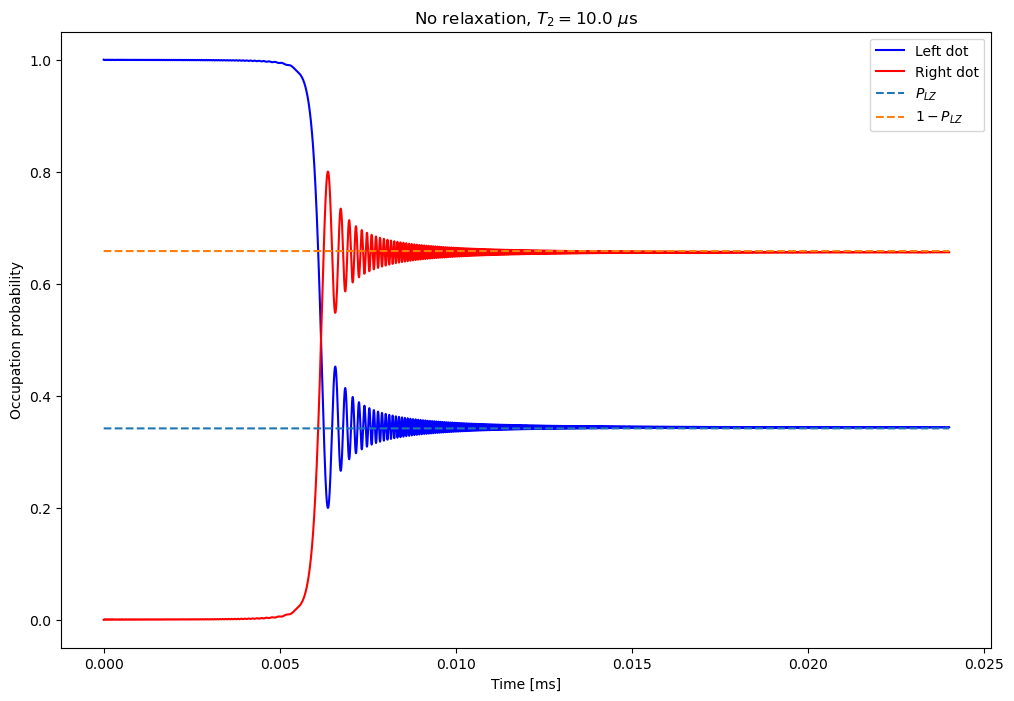

In [36]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(1e3*tlist, np.real(result), "b", 1e3*tlist, np.real(1 - result), "r")
ax.set_xlabel("Time [ms]")
ax.set_ylabel("Occupation probability")

ax.plot(1e3*tlist, plz(v)*np.ones(tlist.shape[0]), "--")
ax.plot(1e3*tlist, 1 - plz(v)*np.ones(tlist.shape[0]), "--")

ax.legend(("Left dot", "Right dot", "$P_{LZ}$", "$1 - P_{LZ}$"), loc=0);

title = ''
if gamma_rel == 0:
    title = title + 'No relaxation, '
else:
    title = title + '$T_1 = $' + time_str(gamma_rel) + ',  '

if gamma_deph == 0:
    title = title + 'no dephasing'
else:
    title = title + '$T_2 = $' + time_str(gamma_deph)
plt.title(title)

plt.show()

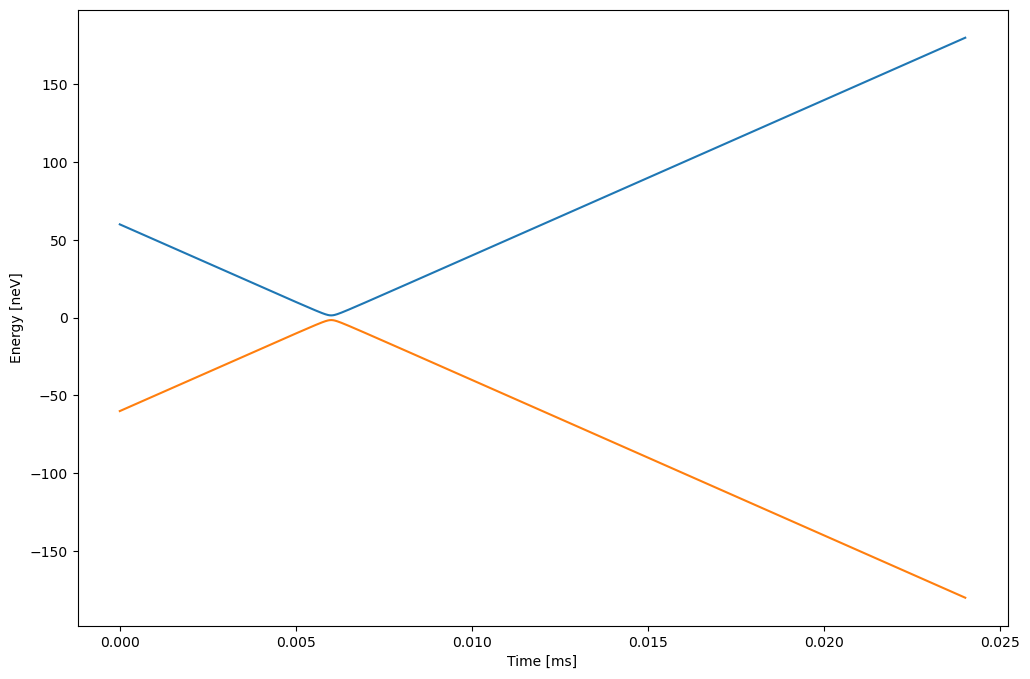

In [53]:
fig, ax = energy_levels(epsilon0, epsilon_f, delta, v)
#ax.set_ylim([-2.5, 2.5])